In [63]:
# Standard libraries
import sys
# Add your custom path
gems_tco_path = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
sys.path.append(gems_tco_path)
import os
import logging
import argparse # Argument parsing

# Data manipulation and analysis
import pandas as pd
import numpy as np
import pickle
import torch
import torch.optim as optim
import copy                    # clone tensor
import time

# Custom imports


from GEMS_TCO import kernels_reparam_space_time_gpu as kernels_reparam_space_time
from GEMS_TCO import orderings as _orderings 
from GEMS_TCO import alg_optimization, BaseLogger

from typing import Optional, List, Tuple
from pathlib import Path
import typer
import json
from json import JSONEncoder
from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed, exact_location_filter

from torch.nn import Parameter

In [64]:
space: List[str] = ['1', '1']
lat_lon_resolution = [int(s) for s in space]
mm_cond_number: int = 8
years = ['2024']
years = ['2025']
month_range = [7] 

output_path = input_path = Path(config.mac_estimates_day_path)
data_load_instance = load_data_dynamic_processed(config.mac_data_load_path)

#lat_range_input = [1, 3]
#lon_range_input = [125.0, 129.0]

lat_range_input=[0,5]      
lon_range_input=[123, 133.0] 

lat_range_input=[-3,2]      
lon_range_input=[121, 131] 


df_map, ord_mm, nns_map, day_offsets = data_load_instance.load_maxmin_ordered_data_bymonthyear(
lat_lon_resolution=lat_lon_resolution, 
mm_cond_number=mm_cond_number,
years_=years, 
months_=month_range,

lat_range=lat_range_input,   
lon_range=lon_range_input,
is_whittle= False
  
)

--- Global Monthly Mean for 2025-7: 241.4412 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---


In [65]:
daily_aggregated_tensors_dw = [] 
daily_hourly_maps_dw = []      

daily_aggregated_tensors_vecc = [] 
daily_hourly_maps_vecc = []   


for day_index in range(31):
    hour_start_index = day_index * 8
    
    hour_end_index = (day_index + 1) * 8
    #hour_end_index = day_index*8 + 1
    hour_indices = [hour_start_index, hour_end_index]

    # --- DW용 데이터 로드 (day_offsets 인자 추가) ---
    day_hourly_map, day_aggregated_tensor = data_load_instance.load_working_data(
        df_map, 
        day_offsets,  # <--- 이 부분이 추가되어야 합니다
        hour_indices, 
        ord_mm=ord_mm,
        dtype=torch.float64, 
        keep_ori=True
    )

    daily_aggregated_tensors_dw.append( day_aggregated_tensor )
    daily_hourly_maps_dw.append( day_hourly_map )



그리드 분석

--- Visualizing and Quantifying Jitter (Day Index: 0) ---
📍 Center: Lat 0.000, Lon 125.000 | Window: ±0.3°
--------------------------------------------------
🎯 [Quantification of Sigma Epsilon]
Empirical Sigma_Epsilon (Latitude) : 0.0052 degrees
Empirical Sigma_Epsilon (Longitude): 0.0201 degrees
Grid Resolution (Lat x Lon)        : 0.044 x 0.063
--------------------------------------------------


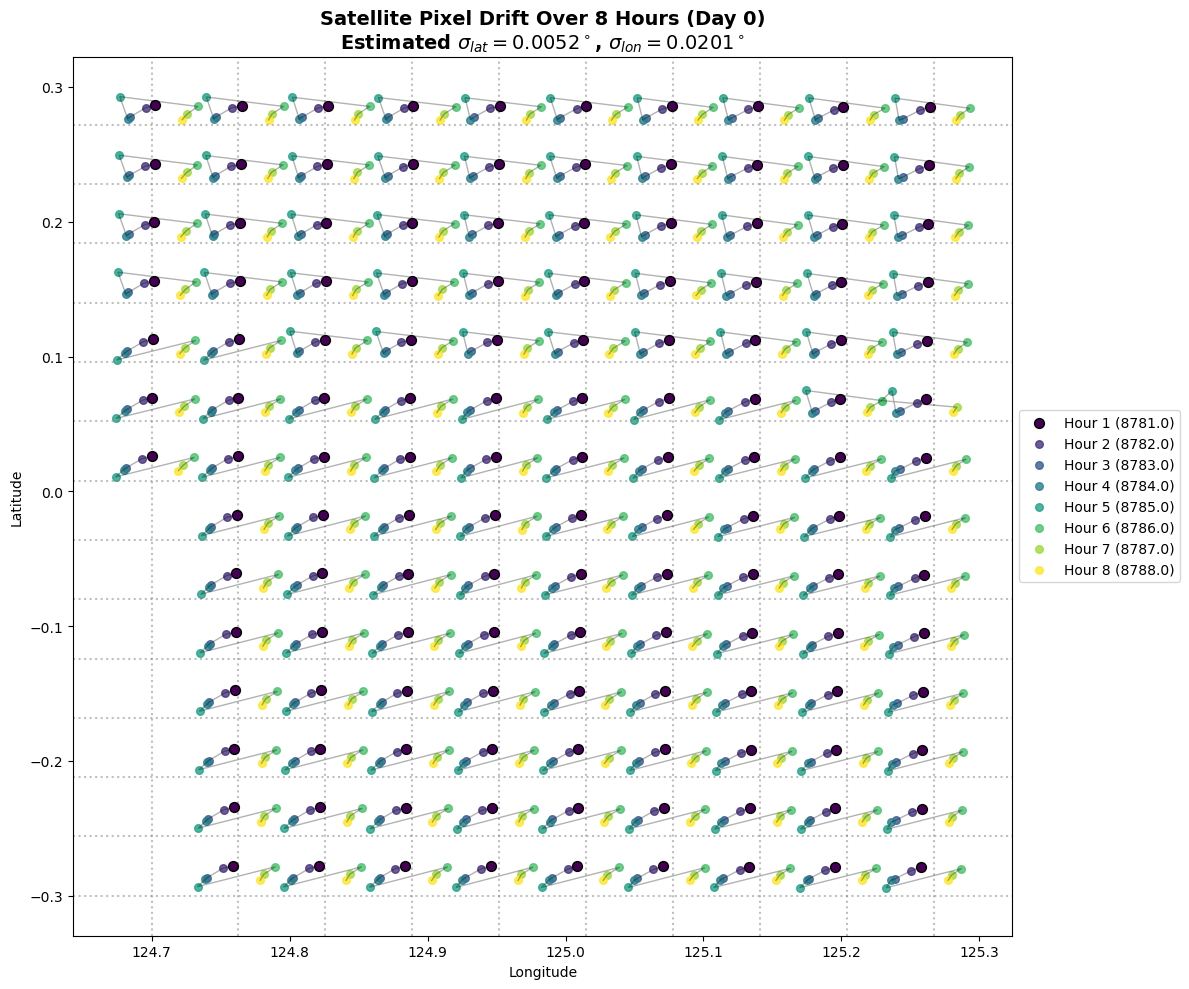

In [66]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.spatial import KDTree

def visualize_and_quantify_jitter(
    tensor_list, 
    day_idx=0,           # [추가] 원하는 날짜(인덱스) 선택
    center_lat=None,     # [추가] 원하는 중심 위도 지정 (None이면 자동)
    center_lon=None,     # [추가] 원하는 중심 경도 지정 (None이면 자동)
    window=0.5,          # [수정] 기본 창 크기 (더 넓게 보고 싶으면 1.0, 2.0 등으로 키우기)
    max_jitter_dist=0.2, # [추가] 궤적 매칭 시 허용하는 최대 거리 (도 단위)
    draw_grid=True       # [추가] 배경 격자선 그리기 켬/끔
):
    """
    특정 날짜와 지정된 지역을 기준으로 8시간 동안의 좌표 이동 궤적을 시각화하고,
    실제 Jitter(sigma_epsilon)를 정량화합니다.
    """
    if len(tensor_list) == 0 or day_idx >= len(tensor_list):
        print(f"Error: Tensor list is empty or day_idx ({day_idx}) is out of bounds.")
        return
    
    # 1. 원하는 날짜 선택
    day_tensor = tensor_list[day_idx]
    times = torch.unique(day_tensor[:, 3], sorted=True).cpu().numpy()
    
    base_mask_init = (day_tensor[:, 3] == times[0])
    base_coords_init = day_tensor[base_mask_init, :2].cpu().numpy()
    
    if len(base_coords_init) == 0:
        print(f"Error: No data in the first time step for Day Index {day_idx}.")
        return
        
    # 2. 중심 좌표 설정 (사용자 입력 우선, 없으면 자동)
    if center_lat is not None and center_lon is not None:
        lat_center = center_lat
        lon_center = center_lon
    else:
        lat_center = np.median(base_coords_init[:, 0])
        lon_center = np.median(base_coords_init[:, 1])
    
    print(f"--- Visualizing and Quantifying Jitter (Day Index: {day_idx}) ---")
    print(f"📍 Center: Lat {lat_center:.3f}, Lon {lon_center:.3f} | Window: ±{window}°")
    
    # 3. 시각화 세팅
    fig, ax = plt.subplots(figsize=(12, 10))
    colors = cm.viridis(np.linspace(0, 1, len(times)))
    
    DELTA_LAT = 0.044
    DELTA_LON = 0.063
    
    # 격자선 그리기 (범위가 너무 넓으면 끄는 것을 권장)
    if draw_grid:
        lat_grids = np.arange(lat_center - window, lat_center + window, DELTA_LAT)
        lon_grids = np.arange(lon_center - window, lon_center + window, DELTA_LON)
        for glat in lat_grids:
            ax.axhline(glat, color='gray', linestyle=':', alpha=0.5)
        for glon in lon_grids:
            ax.axvline(glon, color='gray', linestyle=':', alpha=0.5)

    # 4. 돋보기 영역의 Base 포인트 추적
    base_mask = (day_tensor[:, 3] == times[0]) & \
                (day_tensor[:, 0] >= lat_center - window) & (day_tensor[:, 0] <= lat_center + window) & \
                (day_tensor[:, 1] >= lon_center - window) & (day_tensor[:, 1] <= lon_center + window)
    
    base_coords = day_tensor[base_mask, :2].cpu().numpy()
    num_points = len(base_coords)
    
    if num_points == 0:
        print("해당 영역(Window) 내에 데이터가 없습니다. 중심 좌표나 범위를 조정해보세요.")
        return

    trajectories = np.full((num_points, len(times), 2), np.nan)
    trajectories[:, 0, :] = base_coords
    
    ax.scatter(base_coords[:, 1], base_coords[:, 0], color=colors[0], label=f'Hour 1 ({times[0]})', s=50, edgecolors='k', zorder=5)

    # 5. 나머지 시간대 매칭 (KDTree)
    for i in range(1, len(times)):
        # 탐색 범위를 window + max_jitter_dist 로 여유 있게 잡음
        curr_mask = (day_tensor[:, 3] == times[i]) & \
                    (day_tensor[:, 0] >= lat_center - window - max_jitter_dist) & (day_tensor[:, 0] <= lat_center + window + max_jitter_dist) & \
                    (day_tensor[:, 1] >= lon_center - window - max_jitter_dist) & (day_tensor[:, 1] <= lon_center + window + max_jitter_dist)
        curr_coords = day_tensor[curr_mask, :2].cpu().numpy()
        
        if len(curr_coords) > 0:
            tree = KDTree(curr_coords)
            distances, indices = tree.query(base_coords)
            
            # 너무 멀리 튄 매칭 방지
            valid = distances < max_jitter_dist
            trajectories[valid, i, :] = curr_coords[indices[valid]]
            
            ax.scatter(curr_coords[indices[valid], 1], curr_coords[indices[valid], 0], 
                       color=colors[i], label=f'Hour {i+1} ({times[i]})', s=30, alpha=0.8)

    # 궤적 선 긋기
    for p in range(num_points):
        track = trajectories[p, :, :]
        valid_track = track[~np.isnan(track[:, 0])]
        if len(valid_track) > 1:
            ax.plot(valid_track[:, 1], valid_track[:, 0], 'k-', alpha=0.3, linewidth=1)

    # 6. 정량화 (Sigma Epsilon)
    var_lat = np.nanvar(trajectories[:, :, 0], axis=1)
    var_lon = np.nanvar(trajectories[:, :, 1], axis=1)
    
    sigma_eps_lat = np.sqrt(np.nanmean(var_lat))
    sigma_eps_lon = np.sqrt(np.nanmean(var_lon))
    
    print("-" * 50)
    print("🎯 [Quantification of Sigma Epsilon]")
    print(f"Empirical Sigma_Epsilon (Latitude) : {sigma_eps_lat:.4f} degrees")
    print(f"Empirical Sigma_Epsilon (Longitude): {sigma_eps_lon:.4f} degrees")
    print(f"Grid Resolution (Lat x Lon)        : {DELTA_LAT:.3f} x {DELTA_LON:.3f}")
    print("-" * 50)
    
    if sigma_eps_lat > DELTA_LAT or sigma_eps_lon > DELTA_LON:
        print("⚠️ 결론: Jitter의 크기가 격자 크기를 초과합니다! (무시 불가)")

    ax.set_title(rf"Satellite Pixel Drift Over 8 Hours (Day {day_idx})" "\n" rf"Estimated $\sigma_{{lat}}={sigma_eps_lat:.4f}^\circ$, $\sigma_{{lon}}={sigma_eps_lon:.4f}^\circ$", fontsize=14, fontweight='bold')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.grid(False)
    plt.tight_layout()
    plt.show()

# visualize_and_quantify_jitter(daily_aggregated_tensors_dw, day_idx=2, window=1.0, draw_grid=False)

#

visualize_and_quantify_jitter(daily_aggregated_tensors_dw, day_idx=0, center_lat=0, center_lon=125.0, window=0.3)

평균적으로 격자를 얼마나 이동시켜야 하는지 알아보자 latitude 는 격자 크기에 비해 작아서 무시 가능 longitude 는 아닌데

나중에 advection estimate에서 뺴주기 위해 linear 하게 계산해도 좋을 듯

--- 30-Day Average Drift Analysis ---
Target Anchor: Lat -0.5, Lon 126.0
분석에 성공한 유효 날짜 수: 26 / 31 일
KDTree에서 제외한 non-finite 좌표 수: 142589

[Hour별 평균 이동량 (Hour 1 기준)]
Hour 1: ΔLat = 0.00000°, ΔLon = 0.00000°
Hour 2: ΔLat = -0.00286°, ΔLon = -0.00565°
Hour 3: ΔLat = -0.00367°, ΔLon = -0.01361°
Hour 4: ΔLat = -0.00235°, ΔLon = -0.01465°
Hour 5: ΔLat = -0.00280°, ΔLon = -0.01871°
Hour 6: ΔLat = 0.00194°, ΔLon = -0.02693°
Hour 7: ΔLat = -0.00040°, ΔLon = -0.02923°
Hour 8: ΔLat = 0.00330°, ΔLon = -0.03475°


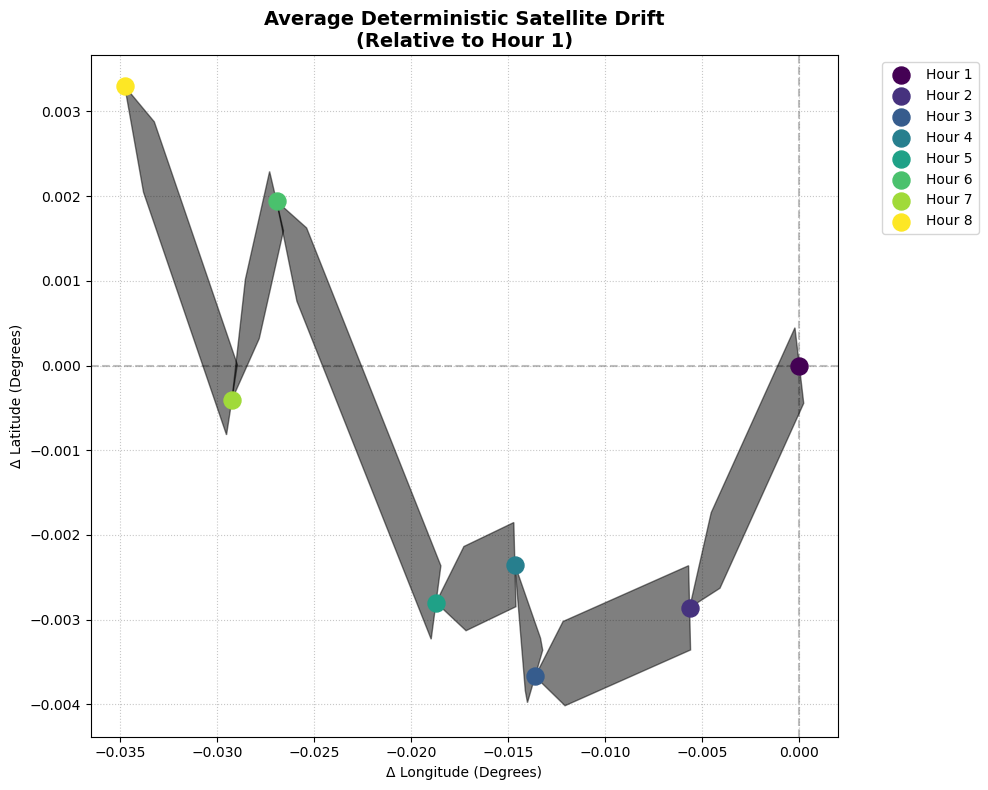

In [67]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree


def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _finite_coords(arr, coord_cols=(0, 1)):
    coords = np.asarray(arr[:, coord_cols], dtype=float)
    good = np.isfinite(coords).all(axis=1)
    return coords[good], good


def visualize_30day_average_drift(tensor_list, target_lat=-0.5, target_lon=126.0):
    """
    30일간의 데이터를 분석하여, 특정 중심 좌표 부근에서
    시간대별(Hour 1~8) 위성 픽셀의 평균적인 편이(Drift) 궤적을 시각화합니다.

    NaN/Inf 좌표는 KDTree에 넣기 전에 제거합니다.
    """
    if len(tensor_list) == 0:
        print("Error: Tensor list is empty.")
        return None

    delta_lats_per_hour = [[] for _ in range(8)]
    delta_lons_per_hour = [[] for _ in range(8)]
    valid_days = 0
    skipped_nonfinite = 0

    print("--- 30-Day Average Drift Analysis ---")
    print(f"Target Anchor: Lat {target_lat}, Lon {target_lon}")

    for day_idx, day_tensor in enumerate(tensor_list):
        arr_day = _to_numpy(day_tensor)
        if arr_day.ndim != 2 or arr_day.shape[1] < 4:
            continue
        valid_time = np.isfinite(arr_day[:, 3])
        times = np.unique(arr_day[valid_time, 3])
        times = np.sort(times)
        if len(times) < 8:
            continue

        mask_h1 = arr_day[:, 3] == times[0]
        coords_h1, good_h1 = _finite_coords(arr_day[mask_h1], coord_cols=(0, 1))
        skipped_nonfinite += int((~good_h1).sum())
        if len(coords_h1) == 0:
            continue

        tree_h1 = KDTree(coords_h1)
        _, idx_h1 = tree_h1.query([[target_lat, target_lon]])
        base_point = coords_h1[int(idx_h1[0])]

        day_lats = [0.0]
        day_lons = [0.0]
        curr_point = base_point.copy()
        track_successful = True

        for h_idx in range(1, 8):
            mask_h = arr_day[:, 3] == times[h_idx]
            coords_h, good_h = _finite_coords(arr_day[mask_h], coord_cols=(0, 1))
            skipped_nonfinite += int((~good_h).sum())
            if len(coords_h) == 0:
                track_successful = False
                break

            tree_h = KDTree(coords_h)
            dist, idx_h = tree_h.query([curr_point])
            if not np.isfinite(dist[0]) or dist[0] > 0.05:
                track_successful = False
                break

            curr_point = coords_h[int(idx_h[0])]
            day_lats.append(float(curr_point[0] - base_point[0]))
            day_lons.append(float(curr_point[1] - base_point[1]))

        if track_successful and len(day_lats) == 8:
            valid_days += 1
            for h in range(8):
                delta_lats_per_hour[h].append(day_lats[h])
                delta_lons_per_hour[h].append(day_lons[h])

    print(f"분석에 성공한 유효 날짜 수: {valid_days} / {len(tensor_list)} 일")
    print(f"KDTree에서 제외한 non-finite 좌표 수: {skipped_nonfinite}")

    if valid_days == 0:
        print("유효한 궤적을 찾지 못했습니다.")
        return None

    mean_d_lats = [float(np.nanmean(delta_lats_per_hour[h])) for h in range(8)]
    mean_d_lons = [float(np.nanmean(delta_lons_per_hour[h])) for h in range(8)]

    print("\n[Hour별 평균 이동량 (Hour 1 기준)]")
    for h in range(8):
        print(f"Hour {h+1}: ΔLat = {mean_d_lats[h]:.5f}°, ΔLon = {mean_d_lons[h]:.5f}°")

    plt.figure(figsize=(10, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, 8))
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

    for h in range(8):
        plt.scatter(mean_d_lons[h], mean_d_lats[h], color=colors[h], s=150, zorder=5, label=f'Hour {h+1}')
        if h > 0:
            plt.arrow(
                mean_d_lons[h-1], mean_d_lats[h-1],
                mean_d_lons[h] - mean_d_lons[h-1], mean_d_lats[h] - mean_d_lats[h-1],
                color='k', alpha=0.5, head_width=0.001, head_length=0.0015,
                length_includes_head=True, zorder=4,
            )

    plt.title("Average Deterministic Satellite Drift\n(Relative to Hour 1)", fontsize=14, fontweight='bold')
    plt.xlabel("Δ Longitude (Degrees)")
    plt.ylabel("Δ Latitude (Degrees)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return mean_d_lats, mean_d_lons


result = visualize_30day_average_drift(
    daily_aggregated_tensors_dw,
    target_lat=-0.5,
    target_lon=126.0,
)
if result is not None:
    mean_d_lats, mean_d_lons = result


이제 격자 이동시킬 건 알았는데 위치 시작점을 연구하자

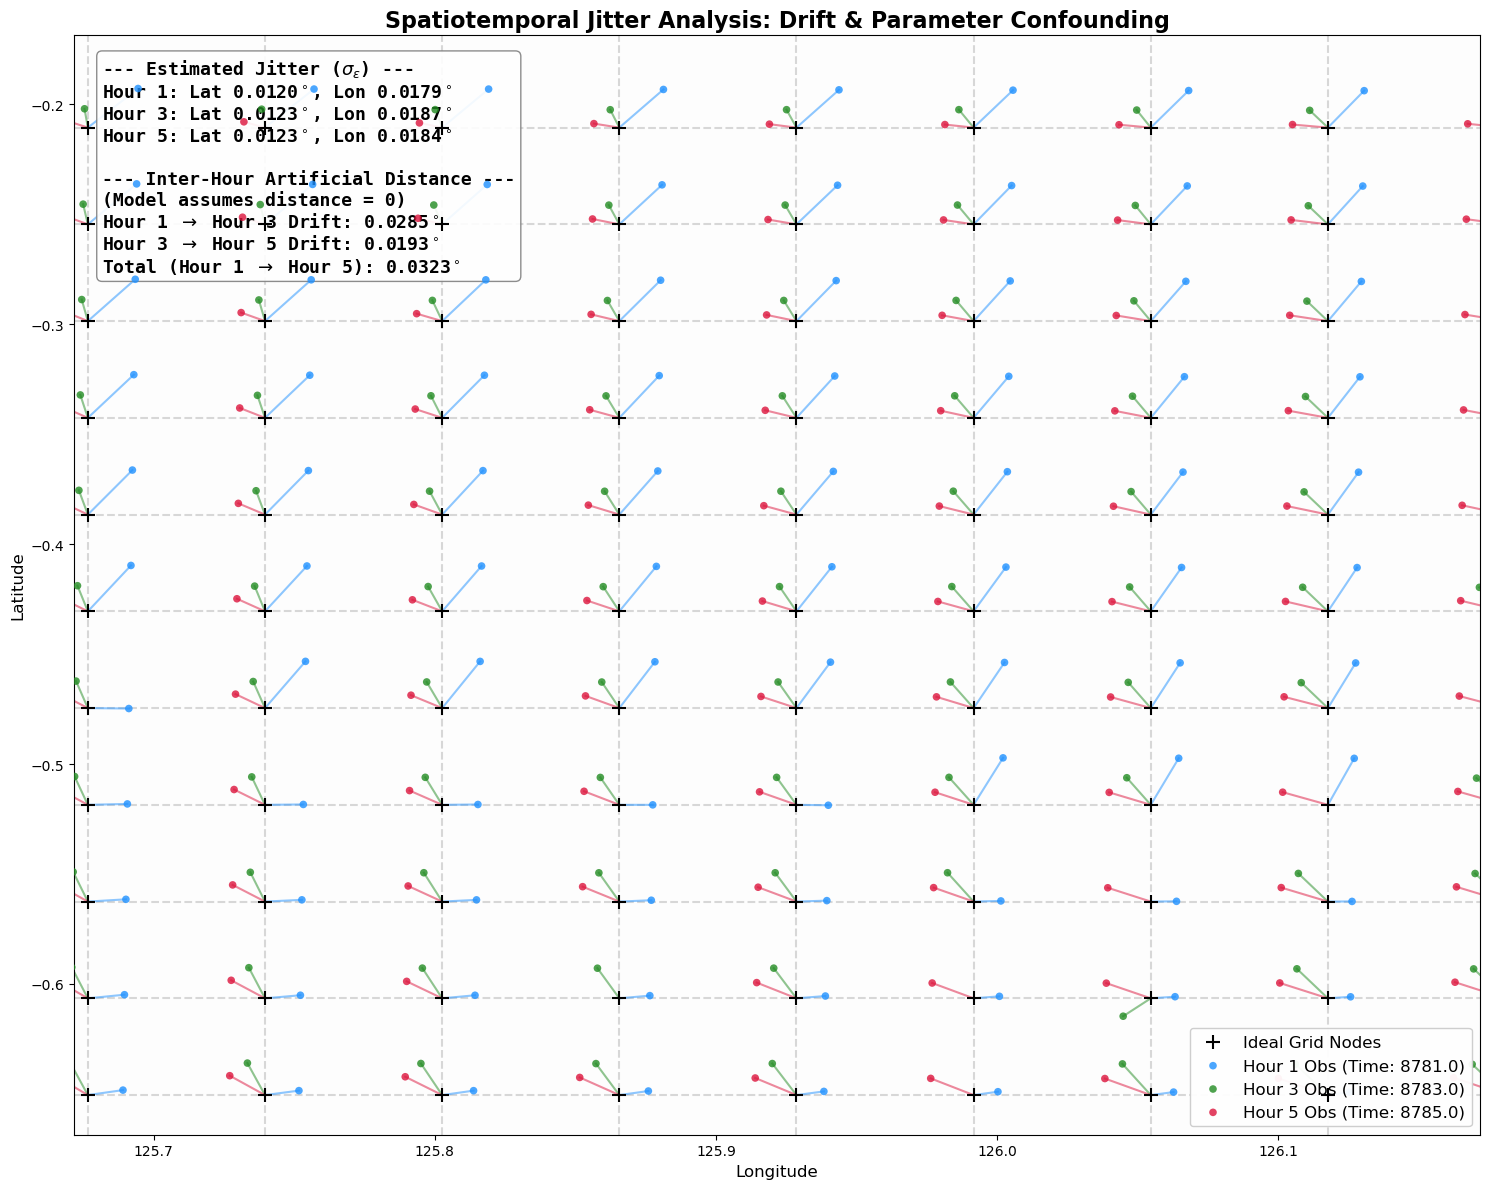

In [68]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

DELTA_LAT = 0.044
DELTA_LON = 0.063
HALF_LAT = DELTA_LAT / 2.0
HALF_LON = DELTA_LON / 2.0

def visualize_dynamic_jitter_with_stats(tensor_list, time_indices=[0, 2, 4], window=0.3):
    """
    여러 시간대의 그리드 매칭 결과를 겹쳐서 시각화하고,
    시간대별 Sigma Epsilon 및 시간 간 표류(Drift) 거리를 추정하여 출력합니다.
    """
    if len(tensor_list) == 0:
        return
    
    day_tensor = tensor_list[0]
    times = torch.unique(day_tensor[:, 3], sorted=True)
    
    # 1. 기준 좌표 설정
    t_base = times[time_indices[0]]
    coords_base = day_tensor[day_tensor[:, 3] == t_base, :2].detach().cpu().numpy()
    coords_base = coords_base[np.isfinite(coords_base).all(axis=1)]
    if len(coords_base) == 0:
        print('No finite base coordinates for the selected time index.')
        return
    
    lat_center = np.median(coords_base[:, 0])
    lon_center = np.median(coords_base[:, 1])
    
    # 2. 전체 격자 생성
    lat_min, lat_max = coords_base[:, 0].min(), coords_base[:, 0].max()
    lon_min, lon_max = coords_base[:, 1].min(), coords_base[:, 1].max()
    
    grid_lats_full = np.arange(lat_min - DELTA_LAT, lat_max + DELTA_LAT, DELTA_LAT)
    grid_lons_full = np.arange(lon_min - DELTA_LON, lon_max + DELTA_LON, DELTA_LON)
    
    GLON_full, GLAT_full = np.meshgrid(grid_lons_full, grid_lats_full)
    grid_points_full = np.column_stack([GLAT_full.ravel(), GLON_full.ravel()])
    num_grids = len(grid_points_full)
    
    # 3. 시각화 세팅
    fig, ax = plt.subplots(figsize=(15, 12))
    
    draw_lats = grid_lats_full[(grid_lats_full >= lat_center - window) & (grid_lats_full <= lat_center + window)]
    draw_lons = grid_lons_full[(grid_lons_full >= lon_center - window) & (grid_lons_full <= lon_center + window)]
    
    for glat in draw_lats: ax.axhline(glat, color='gray', linestyle='--', alpha=0.3)
    for glon in draw_lons: ax.axvline(glon, color='gray', linestyle='--', alpha=0.3)

    GLON_view, GLAT_view = np.meshgrid(draw_lons, draw_lats)
    ax.scatter(GLON_view, GLAT_view, marker='+', color='black', s=100, linewidths=1.5, zorder=10, label='Ideal Grid Nodes')

    colors = ['dodgerblue', 'forestgreen', 'crimson']
    labels = [f"Hour {idx+1}" for idx in time_indices]
    
    # 통계 기록용 배열 [시간대 개수, 전체 격자 개수, 2(lat/lon)]
    mapped_obs_history = np.full((len(time_indices), num_grids, 2), np.nan)
    sigma_eps_list = []
    
    # 4. 각 시간대별 매칭 및 Jitter 계산
    for c_idx, t_idx in enumerate(time_indices):
        if t_idx >= len(times): continue
        
        t_target = times[t_idx]
        coords = day_tensor[day_tensor[:, 3] == t_target, :2].detach().cpu().numpy()
        coords = coords[np.isfinite(coords).all(axis=1)]
        
        if len(coords) == 0: continue
            
        tree = KDTree(coords)
        distances, indices = tree.query(grid_points_full)
        matched_all = coords[indices]
        valid_match = (
            (np.abs(matched_all[:, 0] - grid_points_full[:, 0]) <= HALF_LAT)
            & (np.abs(matched_all[:, 1] - grid_points_full[:, 1]) <= HALF_LON)
        )
        
        current_color = colors[c_idx % len(colors)]
        plotted_obs_indices = set()
        
        # Intra-hour Jitter (Sigma Epsilon) 계산
        matched_obs_coords = np.full_like(grid_points_full, np.nan, dtype=float)
        matched_obs_coords[valid_match] = matched_all[valid_match]
        mapped_obs_history[c_idx, :, :] = matched_obs_coords
        
        rmse_lat = np.sqrt(np.nanmean((matched_obs_coords[:, 0] - grid_points_full[:, 0])**2))
        rmse_lon = np.sqrt(np.nanmean((matched_obs_coords[:, 1] - grid_points_full[:, 1])**2))
        sigma_eps_list.append((rmse_lat, rmse_lon))
        
        # 시각화 선 긋기 (화면 안쪽만)
        for i, grid_pt in enumerate(grid_points_full):
            if not valid_match[i]:
                continue
            obs_idx = indices[i]
            obs_pt = coords[obs_idx]
            
            in_view = ((lat_center - window <= grid_pt[0] <= lat_center + window) and 
                       (lon_center - window <= grid_pt[1] <= lon_center + window)) or \
                      ((lat_center - window <= obs_pt[0] <= lat_center + window) and 
                       (lon_center - window <= obs_pt[1] <= lon_center + window))
                       
            if in_view:
                plotted_obs_indices.add(obs_idx)
                ax.plot([grid_pt[1], obs_pt[1]], [grid_pt[0], obs_pt[0]], 
                        color=current_color, alpha=0.5, linewidth=1.5)
        
        if plotted_obs_indices:
            used_list = list(plotted_obs_indices)
            ax.scatter(coords[used_list, 1], coords[used_list, 0], 
                       color=current_color, s=30, edgecolors='none', zorder=5, alpha=0.8,
                       label=f'{labels[c_idx]} Obs (Time: {t_target.item()})')

    # 5. 시간 간 표류 (Inter-Hour Drift / Artificial Distance) 계산
    drift_text = ""
    if len(time_indices) >= 2:
        dist_0_1 = np.sqrt((mapped_obs_history[0,:,0] - mapped_obs_history[1,:,0])**2 + 
                           (mapped_obs_history[0,:,1] - mapped_obs_history[1,:,1])**2)
        mean_drift_0_1 = np.nanmean(dist_0_1)
        drift_text += f"{labels[0]} $\\rightarrow$ {labels[1]} Drift: {mean_drift_0_1:.4f}$^\\circ$\n"
        
    if len(time_indices) >= 3:
        dist_1_2 = np.sqrt((mapped_obs_history[1,:,0] - mapped_obs_history[2,:,0])**2 + 
                           (mapped_obs_history[1,:,1] - mapped_obs_history[2,:,1])**2)
        mean_drift_1_2 = np.nanmean(dist_1_2)
        drift_text += f"{labels[1]} $\\rightarrow$ {labels[2]} Drift: {mean_drift_1_2:.4f}$^\\circ$\n"
        
        dist_0_2 = np.sqrt((mapped_obs_history[0,:,0] - mapped_obs_history[2,:,0])**2 + 
                           (mapped_obs_history[0,:,1] - mapped_obs_history[2,:,1])**2)
        mean_drift_0_2 = np.nanmean(dist_0_2)
        drift_text += f"Total ({labels[0]} $\\rightarrow$ {labels[2]}): {mean_drift_0_2:.4f}$^\\circ$"

    # 6. 통계 텍스트 박스 출력 (r-string 적용으로 Warning 해결)
    stats_str = r"--- Estimated Jitter ($\sigma_\epsilon$) ---" + "\n"
    for idx, (s_lat, s_lon) in enumerate(sigma_eps_list):
        stats_str += f"{labels[idx]}: Lat {s_lat:.4f}$^\\circ$, Lon {s_lon:.4f}$^\\circ$\n"
    stats_str += "\n--- Inter-Hour Artificial Distance ---\n"
    stats_str += "(Model assumes distance = 0)\n"
    stats_str += drift_text
    
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.02, 0.98, stats_str, transform=ax.transAxes, fontsize=13, 
            verticalalignment='top', bbox=props, fontweight='bold', fontfamily='monospace')

    ax.set_title(rf"Spatiotemporal Jitter Analysis: Drift & Parameter Confounding", fontsize=16, fontweight='bold')
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)
    
    ax.set_xlim(lon_center - window, lon_center + window)
    ax.set_ylim(lat_center - window, lat_center + window)
    ax.legend(loc='lower right', fontsize=12, framealpha=0.95)
    ax.set_facecolor('#fdfdfd')
    
    plt.tight_layout()
    plt.show()

# 실행
visualize_dynamic_jitter_with_stats(daily_aggregated_tensors_dw, time_indices=[0, 2, 4], window=0.25)

Contraction of distant points force range parameters to decrease

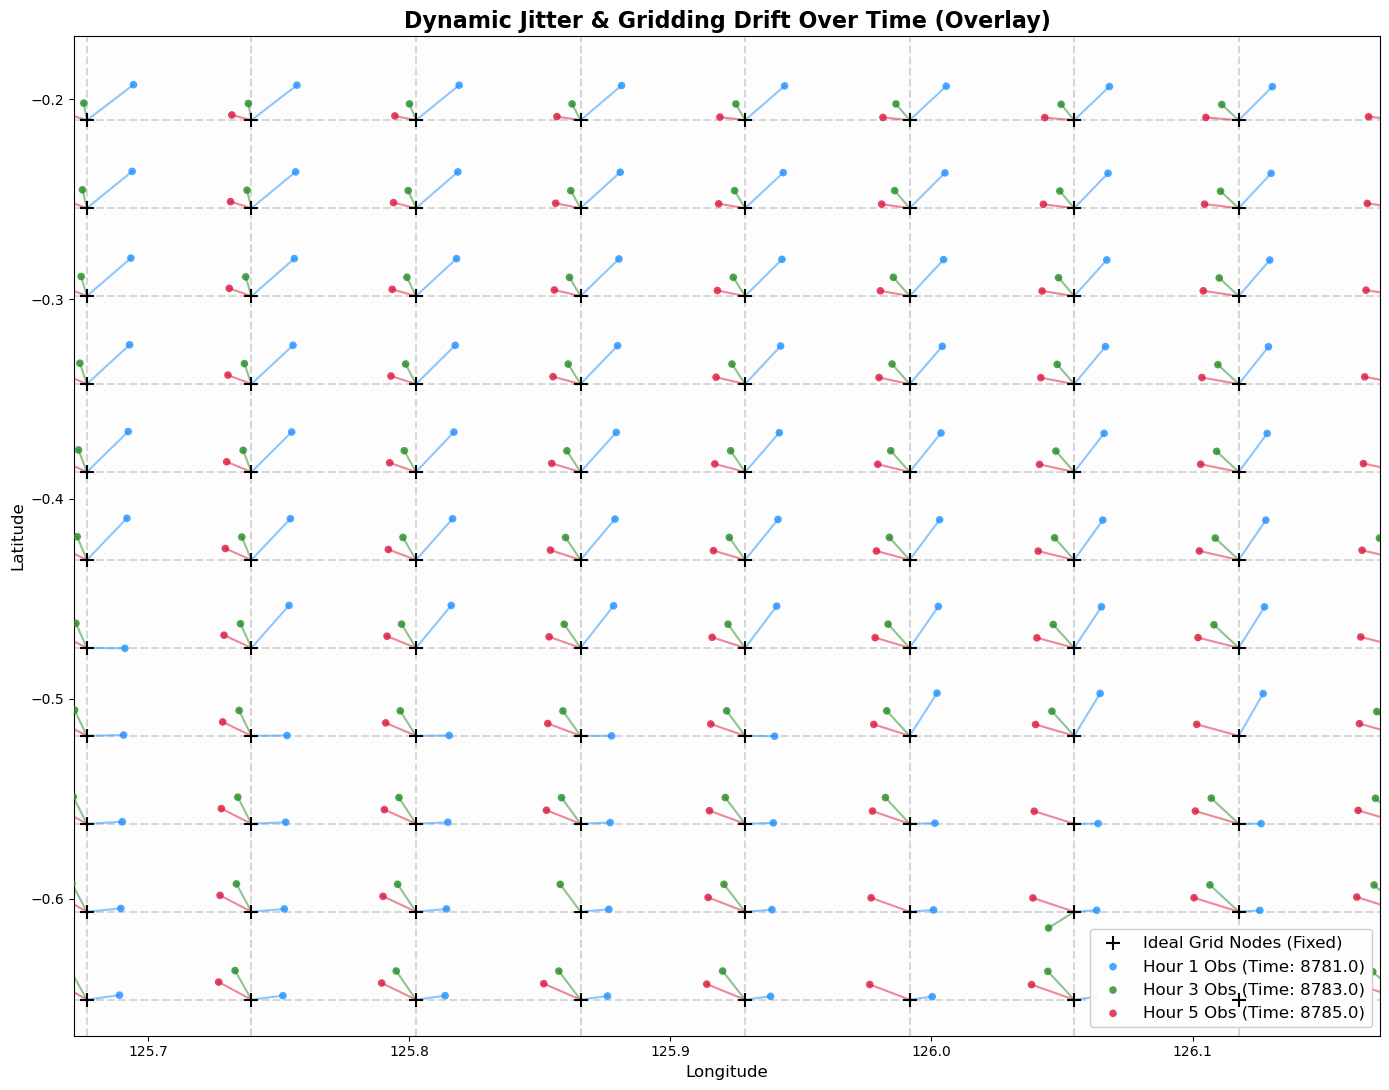

In [69]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

DELTA_LAT = 0.044
DELTA_LON = 0.063
HALF_LAT = DELTA_LAT / 2.0
HALF_LON = DELTA_LON / 2.0

def visualize_dynamic_jitter_overlay(tensor_list, time_indices=[0, 2, 4], window=0.3):
    """
    여러 시간대(예: Hour 1, 3, 5)의 그리드 매칭 결과를 
    하나의 플랏에 색깔별로 겹쳐서(Overlay) 시각화합니다.
    시간이 지남에 따라 격자 매칭이 어떻게 표류(Drift)하는지 보여줍니다.
    """
    if len(tensor_list) == 0:
        return
    
    day_tensor = tensor_list[0]
    times = torch.unique(day_tensor[:, 3], sorted=True)
    
    # 1. 기준 좌표 설정 (첫 번째 주어진 시간대 기준)
    t_base = times[time_indices[0]]
    coords_base = day_tensor[day_tensor[:, 3] == t_base, :2].detach().cpu().numpy()
    coords_base = coords_base[np.isfinite(coords_base).all(axis=1)]
    if len(coords_base) == 0:
        print('No finite base coordinates for the selected time index.')
        return
    
    lat_center = np.median(coords_base[:, 0])
    lon_center = np.median(coords_base[:, 1])
    
    # 2. 경계 효과 방지를 위해 전체 데이터 영역 격자 생성
    lat_min, lat_max = coords_base[:, 0].min(), coords_base[:, 0].max()
    lon_min, lon_max = coords_base[:, 1].min(), coords_base[:, 1].max()
    
    grid_lats_full = np.arange(lat_min - DELTA_LAT, lat_max + DELTA_LAT, DELTA_LAT)
    grid_lons_full = np.arange(lon_min - DELTA_LON, lon_max + DELTA_LON, DELTA_LON)
    
    GLON_full, GLAT_full = np.meshgrid(grid_lons_full, grid_lats_full)
    grid_points_full = np.column_stack([GLAT_full.ravel(), GLON_full.ravel()])
    
    # 3. 시각화 세팅
    fig, ax = plt.subplots(figsize=(14, 11))
    
    # 화면에 그릴 격자선 필터링
    draw_lats = grid_lats_full[(grid_lats_full >= lat_center - window) & (grid_lats_full <= lat_center + window)]
    draw_lons = grid_lons_full[(grid_lons_full >= lon_center - window) & (grid_lons_full <= lon_center + window)]
    
    # 배경 정규 격자선
    for glat in draw_lats: ax.axhline(glat, color='gray', linestyle='--', alpha=0.3)
    for glon in draw_lons: ax.axvline(glon, color='gray', linestyle='--', alpha=0.3)

    # 이상적인 격자 중심점 (검은 십자가)
    GLON_view, GLAT_view = np.meshgrid(draw_lons, draw_lats)
    ax.scatter(GLON_view, GLAT_view, marker='+', color='black', s=100, linewidths=1.5, zorder=10, label='Ideal Grid Nodes (Fixed)')

    # 시간대별 색상 지정 (파랑, 초록, 빨강)
    colors = ['dodgerblue', 'forestgreen', 'crimson']
    labels = [f"Hour {idx+1}" for idx in time_indices]
    
    # 4. 각 시간대별로 매칭 선 긋기 Loop
    for c_idx, t_idx in enumerate(time_indices):
        if t_idx >= len(times): continue
        
        t_target = times[t_idx]
        coords = day_tensor[day_tensor[:, 3] == t_target, :2].detach().cpu().numpy()
        coords = coords[np.isfinite(coords).all(axis=1)]
        
        if len(coords) == 0: continue
            
        # KDTree 매칭: accept only axis-wise half-cell matches.
        tree = KDTree(coords)
        distances, indices = tree.query(grid_points_full)
        matched_all = coords[indices]
        valid_match = (
            (np.abs(matched_all[:, 0] - grid_points_full[:, 0]) <= HALF_LAT)
            & (np.abs(matched_all[:, 1] - grid_points_full[:, 1]) <= HALF_LON)
        )
        
        current_color = colors[c_idx % len(colors)]
        plotted_obs_indices = set()
        
        # 선 긋기
        for i, grid_pt in enumerate(grid_points_full):
            if not valid_match[i]:
                continue
            obs_idx = indices[i]
            obs_pt = coords[obs_idx]
            
            # 화면(Window) 안에 들어오는 것만 그림
            in_view = ((lat_center - window <= grid_pt[0] <= lat_center + window) and 
                       (lon_center - window <= grid_pt[1] <= lon_center + window)) or \
                      ((lat_center - window <= obs_pt[0] <= lat_center + window) and 
                       (lon_center - window <= obs_pt[1] <= lon_center + window))
                       
            if in_view:
                plotted_obs_indices.add(obs_idx)
                # 격자점에서 실제 데이터로 이어지는 매칭 선
                ax.plot([grid_pt[1], obs_pt[1]], [grid_pt[0], obs_pt[0]], 
                        color=current_color, alpha=0.5, linewidth=1.5)
        
        # 해당 시간대의 실제 관측점(점) 찍기
        if plotted_obs_indices:
            used_list = list(plotted_obs_indices)
            ax.scatter(coords[used_list, 1], coords[used_list, 0], 
                       color=current_color, s=30, edgecolors='none', zorder=5, alpha=0.8,
                       label=f'{labels[c_idx]} Obs (Time: {t_target.item()})')

    # 5. 그래프 꾸미기
    ax.set_title(rf"Dynamic Jitter & Gridding Drift Over Time (Overlay)", fontsize=16, fontweight='bold')
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)
    
    ax.set_xlim(lon_center - window, lon_center + window)
    ax.set_ylim(lat_center - window, lat_center + window)
    
    # 범례 설정
    ax.legend(loc='lower right', fontsize=12, framealpha=0.95)
    ax.set_facecolor('#fdfdfd')
    
    plt.tight_layout()
    plt.show()

# 실행: Hour 1(파랑), Hour 3(초록), Hour 5(빨강)를 한 플랏에 겹쳐 그리기
visualize_dynamic_jitter_overlay(daily_aggregated_tensors_dw, time_indices=[0, 2, 4], window=0.25)

--- Checking Grid Stability over 23 days ---
Target hour index: 4
Axis-wise match threshold: lat <= 0.0220, lon <= 0.0315
Reference: day=0, key=2025_07_y25m07day01_hm04:48, n_ref=5,000
day 00, key=2025_07_y25m07day01_hm04:48: matches=5,000/5,000 (1.000), median |dlat|=0.000000, median |dlon|=0.000000
day 01, key=2025_07_y25m07day02_hm04:48: matches=4,197/5,000 (0.839), median |dlat|=0.003664, median |dlon|=0.007440
day 02, key=2025_07_y25m07day03_hm04:48: matches=4,916/5,000 (0.983), median |dlat|=0.002917, median |dlon|=0.019830
day 03, key=2025_07_y25m07day04_hm04:48: matches=4,870/5,000 (0.974), median |dlat|=0.001596, median |dlon|=0.016470
day 04, key=2025_07_y25m07day05_hm04:48: matches=4,898/5,000 (0.980), median |dlat|=0.001056, median |dlon|=0.010870
day 05, key=2025_07_y25m07day06_hm04:48: matches=4,628/5,000 (0.926), median |dlat|=0.002631, median |dlon|=0.005780
day 06, key=2025_07_y25m07day07_hm04:48: matches=4,523/5,000 (0.905), median |dlat|=0.005498, median |dlon|=0.001

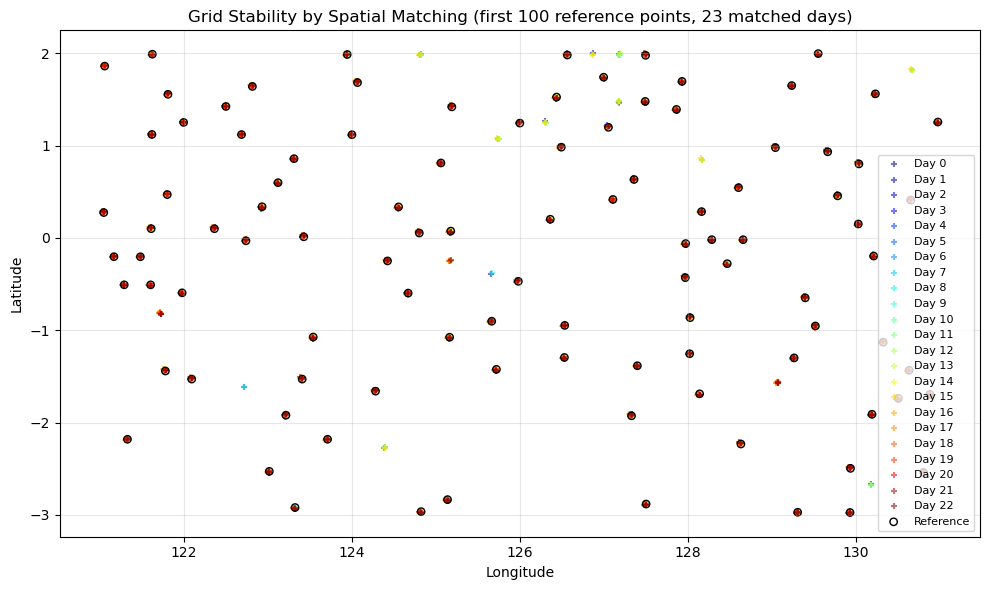

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.spatial import cKDTree

DELTA_LAT = 0.044
DELTA_LON = 0.063
HALF_LAT = DELTA_LAT / 2.0
HALF_LON = DELTA_LON / 2.0


def _to_numpy_safe(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _sorted_hour_keys(day_data):
    try:
        return sorted(day_data.keys(), key=lambda x: int(x) if str(x).isdigit() else str(x))
    except Exception:
        return sorted(day_data.keys(), key=str)


def _finite_coords_from_hour(day_data, target_hour_idx):
    keys = _sorted_hour_keys(day_data)
    if target_hour_idx >= len(keys):
        return None, None
    key = keys[target_hour_idx]
    data = _to_numpy_safe(day_data[key])
    if data.ndim != 2 or data.shape[1] < 2:
        return None, key
    coords = np.asarray(data[:, :2], dtype=float)
    finite = np.isfinite(coords).all(axis=1)
    return coords[finite], key


def _axis_halfcell_match(reference_coords, coords):
    """Match coords to reference_coords with lat/lon half-cell thresholds.

    This avoids comparing row i on one day to row i on another day.  A match is
    accepted only if both coordinate differences are within one half grid cell:
        abs(lat - ref_lat) <= 0.044 / 2
        abs(lon - ref_lon) <= 0.063 / 2
    """
    if len(reference_coords) == 0 or len(coords) == 0:
        return np.empty((0, 2)), np.empty((0, 2)), np.empty(0, dtype=bool)
    tree = cKDTree(coords)
    _, idx = tree.query(reference_coords, k=1)
    matched = coords[idx]
    ok = (
        (np.abs(matched[:, 0] - reference_coords[:, 0]) <= HALF_LAT)
        & (np.abs(matched[:, 1] - reference_coords[:, 1]) <= HALF_LON)
    )
    return reference_coords[ok], matched[ok], ok


def check_grid_stability(data_maps, days_to_check=10, target_hour_idx=4, max_reference_points=5000):
    """
    Check whether coordinates are stable across days without relying on row order.

    The old version compared data[:1000] across days, which is unsafe if the row
    order changes because of maxmin ordering, filtering, or missingness.  This
    version uses day 0 as a spatial reference and matches later days by nearest
    coordinate under axis-wise half-cell thresholds.
    """
    print(f"--- Checking Grid Stability over {days_to_check} days ---")
    print(f"Target hour index: {target_hour_idx}")
    print(f"Axis-wise match threshold: lat <= {HALF_LAT:.4f}, lon <= {HALF_LON:.4f}")

    ref_coords = None
    ref_day = None
    ref_key = None
    for day_idx in range(min(days_to_check, len(data_maps))):
        if data_maps[day_idx] is None:
            continue
        coords, key = _finite_coords_from_hour(data_maps[day_idx], target_hour_idx)
        if coords is not None and len(coords) > 0:
            ref_coords = coords
            ref_day = day_idx
            ref_key = key
            break

    if ref_coords is None:
        print("No usable reference day/hour found.")
        return None

    if len(ref_coords) > max_reference_points:
        # Deterministic spatially spread subset instead of arbitrary first rows.
        take = np.linspace(0, len(ref_coords) - 1, max_reference_points).astype(int)
        ref_coords = ref_coords[take]

    print(f"Reference: day={ref_day}, key={ref_key}, n_ref={len(ref_coords):,}")

    all_lat_delta = []
    all_lon_delta = []
    match_rates = []
    valid_days = 0
    plot_samples = []

    for day_idx in range(min(days_to_check, len(data_maps))):
        if data_maps[day_idx] is None:
            continue
        coords, key = _finite_coords_from_hour(data_maps[day_idx], target_hour_idx)
        if coords is None or len(coords) == 0:
            continue
        ref_match, obs_match, ok = _axis_halfcell_match(ref_coords, coords)
        match_rate = float(ok.mean()) if len(ok) else 0.0
        match_rates.append(match_rate)
        if len(obs_match) == 0:
            print(f"day {day_idx:02d}, key={key}: no half-cell matches")
            continue
        dlat = obs_match[:, 0] - ref_match[:, 0]
        dlon = obs_match[:, 1] - ref_match[:, 1]
        all_lat_delta.append(dlat)
        all_lon_delta.append(dlon)
        valid_days += 1
        plot_samples.append((day_idx, ref_match[:100], obs_match[:100]))
        print(
            f"day {day_idx:02d}, key={key}: matches={len(obs_match):,}/{len(ref_coords):,} "
            f"({match_rate:.3f}), median |dlat|={np.median(np.abs(dlat)):.6f}, "
            f"median |dlon|={np.median(np.abs(dlon)):.6f}"
        )

    if valid_days < 2:
        print("Not enough matched days to compare.")
        return None

    lat_abs = np.concatenate([np.abs(x) for x in all_lat_delta])
    lon_abs = np.concatenate([np.abs(x) for x in all_lon_delta])

    print("\n[Matched-coordinate stability summary]")
    print(f"Valid matched days: {valid_days}")
    print(f"Mean match rate: {np.mean(match_rates):.4f}")
    print(f"Median |Latitude shift| : {np.median(lat_abs):.6f} degrees")
    print(f"Median |Longitude shift|: {np.median(lon_abs):.6f} degrees")
    print(f"P90 |Latitude shift|    : {np.quantile(lat_abs, 0.90):.6f} degrees")
    print(f"P90 |Longitude shift|   : {np.quantile(lon_abs, 0.90):.6f} degrees")

    plt.figure(figsize=(10, 6))
    colors = plt.cm.jet(np.linspace(0, 1, len(plot_samples)))
    for color, (day_idx, ref_s, obs_s) in zip(colors, plot_samples):
        plt.scatter(obs_s[:, 1], obs_s[:, 0], s=18, alpha=0.55, color=color, marker='+', label=f'Day {day_idx}')
    plt.scatter(ref_coords[:100, 1], ref_coords[:100, 0], s=28, facecolors='none', edgecolors='black', label='Reference')
    plt.title(f"Grid Stability by Spatial Matching (first 100 reference points, {valid_days} matched days)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

    return {
        'valid_days': valid_days,
        'mean_match_rate': float(np.mean(match_rates)),
        'median_abs_lat_shift': float(np.median(lat_abs)),
        'median_abs_lon_shift': float(np.median(lon_abs)),
        'p90_abs_lat_shift': float(np.quantile(lat_abs, 0.90)),
        'p90_abs_lon_shift': float(np.quantile(lon_abs, 0.90)),
    }


# 실행
stability_summary = check_grid_stability(daily_hourly_maps_dw, days_to_check=23, target_hour_idx=4)



Quantitative Spatial Analysis (Day 4, Time 6)
Hour key: 2025_07_y25m07day05_hm06:48
Total Data Points: 18,126
Finite coordinate points used: 17,899 (removed 227)

[Nearest-neighbor overlap statistics]
   - Minimum NN Distance: 0.0216848682 degrees
   - Points with NN dist approx 0.0: 0
   - Points with NN dist < 1e-6:   0
   - Points with NN dist < 1e-4:   0

>> 결론: 좌표 간격이 충분히 확보되었습니다.


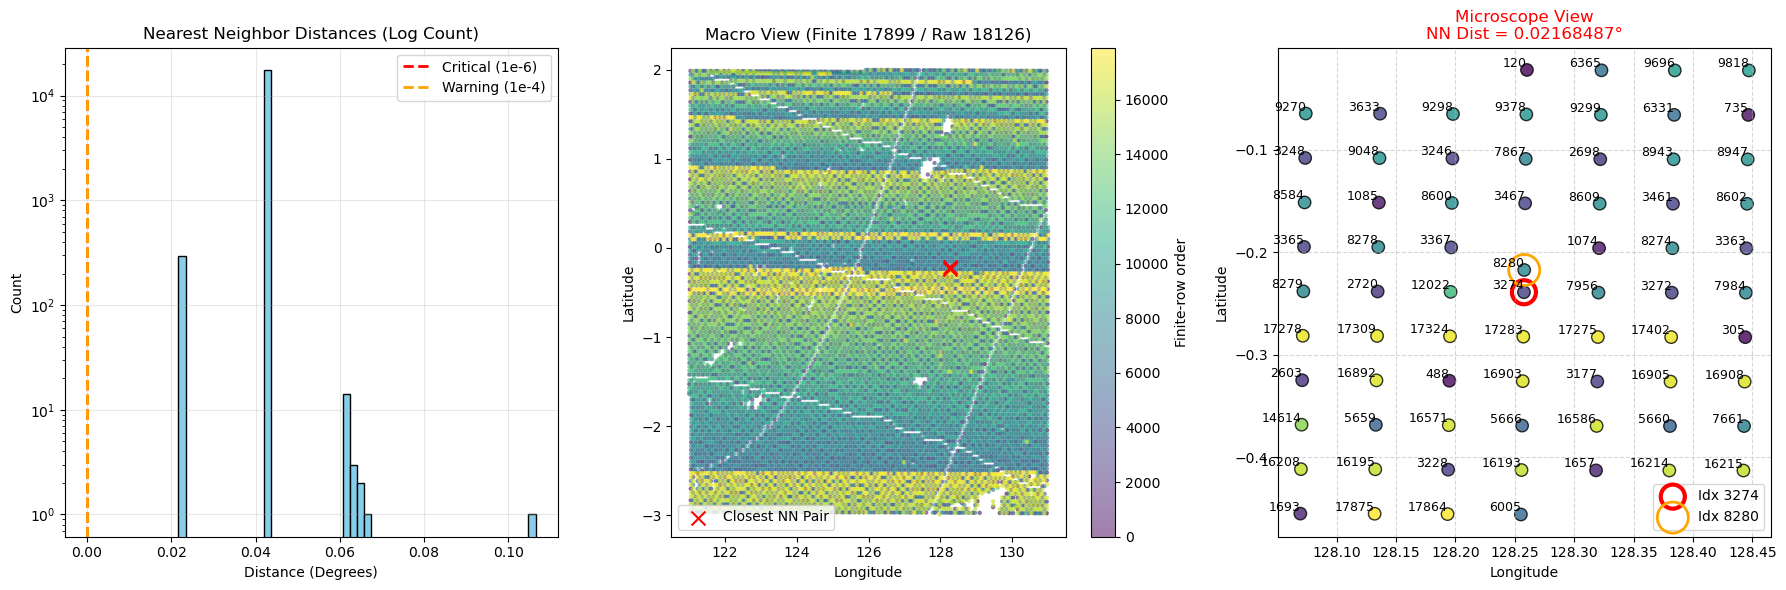

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.spatial import cKDTree


def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def quantify_and_visualize_overlap(data_maps, day_idx=0, time_idx=0):
    """
    Quantify duplicate/near-duplicate coordinates using KDTree k=2.

    The old cdist(coords, coords) path can allocate huge NxN matrices.  k=2 gives
    each point's nearest off-diagonal neighbor directly and is enough for the
    overlap/Cholesky-risk diagnostic.
    """
    print(f"\n{'='*60}")
    print(f"Quantitative Spatial Analysis (Day {day_idx}, Time {time_idx})")
    print(f"{'='*60}")

    if day_idx >= len(data_maps) or data_maps[day_idx] is None:
        print("Error: Data is None or index out of range.")
        return None

    try:
        sorted_keys = sorted(data_maps[day_idx].keys(), key=lambda x: int(x) if str(x).isdigit() else str(x))
    except Exception:
        sorted_keys = sorted(data_maps[day_idx].keys(), key=str)

    if time_idx >= len(sorted_keys):
        print("Error: Time index out of range.")
        return None

    key = sorted_keys[time_idx]
    data = _to_numpy(data_maps[day_idx][key])
    if data.ndim != 2 or data.shape[1] < 2:
        print("Error: expected a 2D array/tensor with coordinate columns 0,1.")
        return None

    coords_raw = np.asarray(data[:, :2], dtype=float)
    finite_mask = np.isfinite(coords_raw).all(axis=1)
    coords = coords_raw[finite_mask]
    N_raw = len(coords_raw)
    N = len(coords)
    print(f"Hour key: {key}")
    print(f"Total Data Points: {N_raw:,}")
    print(f"Finite coordinate points used: {N:,} (removed {N_raw - N:,})")

    if N < 2:
        print("Not enough finite coordinates for nearest-neighbor analysis.")
        return None

    tree = cKDTree(coords)
    nn_dist, nn_idx = tree.query(coords, k=2)
    nearest_neighbor_dists = nn_dist[:, 1]
    nearest_neighbor_indices = nn_idx[:, 1]
    finite_nn = np.isfinite(nearest_neighbor_dists)
    nearest_neighbor_dists = nearest_neighbor_dists[finite_nn]
    nearest_neighbor_indices = nearest_neighbor_indices[finite_nn]
    finite_rows = np.flatnonzero(finite_nn)

    thresh_exact = 1e-12
    thresh_danger = 1e-6
    thresh_warning = 1e-4

    count_exact_points = int(np.sum(nearest_neighbor_dists < thresh_exact))
    count_danger_points = int(np.sum(nearest_neighbor_dists < thresh_danger))
    count_warning_points = int(np.sum(nearest_neighbor_dists < thresh_warning))
    min_pos = int(np.argmin(nearest_neighbor_dists))
    min_val = float(nearest_neighbor_dists[min_pos])
    idx1 = int(finite_rows[min_pos])
    idx2 = int(nearest_neighbor_indices[min_pos])
    p1, p2 = coords[idx1], coords[idx2]

    print("\n[Nearest-neighbor overlap statistics]")
    print(f"   - Minimum NN Distance: {min_val:.10f} degrees")
    print(f"   - Points with NN dist approx 0.0: {count_exact_points}")
    print(f"   - Points with NN dist < 1e-6:   {count_danger_points}")
    print(f"   - Points with NN dist < 1e-4:   {count_warning_points}")

    if count_exact_points > 0 or count_danger_points > 0:
        print("\n>> 결론: 중복되거나 극도로 가까운 좌표가 존재합니다. Cholesky 실패 위험이 큽니다.")
    else:
        print("\n>> 결론: 좌표 간격이 충분히 확보되었습니다.")

    lats, lons = coords[:, 0], coords[:, 1]
    fig = plt.figure(figsize=(18, 6))

    ax1 = fig.add_subplot(1, 3, 1)
    ax1.hist(nearest_neighbor_dists, bins=50, color='skyblue', edgecolor='black', log=True)
    ax1.axvline(thresh_danger, color='red', linestyle='dashed', linewidth=2, label='Critical (1e-6)')
    ax1.axvline(thresh_warning, color='orange', linestyle='dashed', linewidth=2, label='Warning (1e-4)')
    ax1.legend()
    ax1.set_title("Nearest Neighbor Distances (Log Count)", fontsize=12)
    ax1.set_xlabel("Distance (Degrees)")
    ax1.set_ylabel("Count")
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(1, 3, 2)
    sc2 = ax2.scatter(lons, lats, c=np.arange(N), cmap='viridis', s=5, alpha=0.5)
    ax2.scatter([p1[1], p2[1]], [p1[0], p2[0]], color='red', s=100, marker='x', label='Closest NN Pair')
    ax2.set_title(f"Macro View (Finite {N} / Raw {N_raw})", fontsize=12)
    ax2.set_xlabel("Longitude")
    ax2.set_ylabel("Latitude")
    ax2.legend()
    plt.colorbar(sc2, ax=ax2, label='Finite-row order')

    ax3 = fig.add_subplot(1, 3, 3)
    zoom_radius = max(min_val * 10.0, 0.0005)
    mask = (
        (lons > p1[1] - zoom_radius) & (lons < p1[1] + zoom_radius)
        & (lats > p1[0] - zoom_radius) & (lats < p1[0] + zoom_radius)
    )
    subset_lons = lons[mask]
    subset_lats = lats[mask]
    subset_indices = np.arange(N)[mask]

    ax3.scatter(subset_lons, subset_lats, c=subset_indices, cmap='viridis', s=80, alpha=0.8, edgecolor='k')
    ax3.scatter(p1[1], p1[0], s=300, facecolors='none', edgecolors='red', linewidth=3, label=f'Idx {idx1}')
    ax3.scatter(p2[1], p2[0], s=500, facecolors='none', edgecolors='orange', linewidth=2, label=f'Idx {idx2}')

    for x, y, idx in zip(subset_lons, subset_lats, subset_indices):
        ax3.text(x, y, str(idx), fontsize=9, ha='right', va='bottom')

    ax3.set_title(f"Microscope View\nNN Dist = {min_val:.8f}°", fontsize=12, color='red')
    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    return {
        'min_nn_dist': min_val,
        'count_exact_points': count_exact_points,
        'count_danger_points': count_danger_points,
        'count_warning_points': count_warning_points,
        'closest_pair': (idx1, idx2),
        'n_raw': N_raw,
        'n_finite': N,
    }


overlap_summary = quantify_and_visualize_overlap(daily_hourly_maps_dw, 4, 6)


2024

# 2,7 blank on lat:3,5  
# 1,1 blank on lon:130,132
# 10,5 blank on lon:128,130 serious
# 23,3 blank on everywhere
# 1,[4,5,6,7] 132 오른쪽 무

i should choose longitude 120.5 to 130.5 


2025 

# 1,1 big holes 
# 6,6

/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_52772/3458049367.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


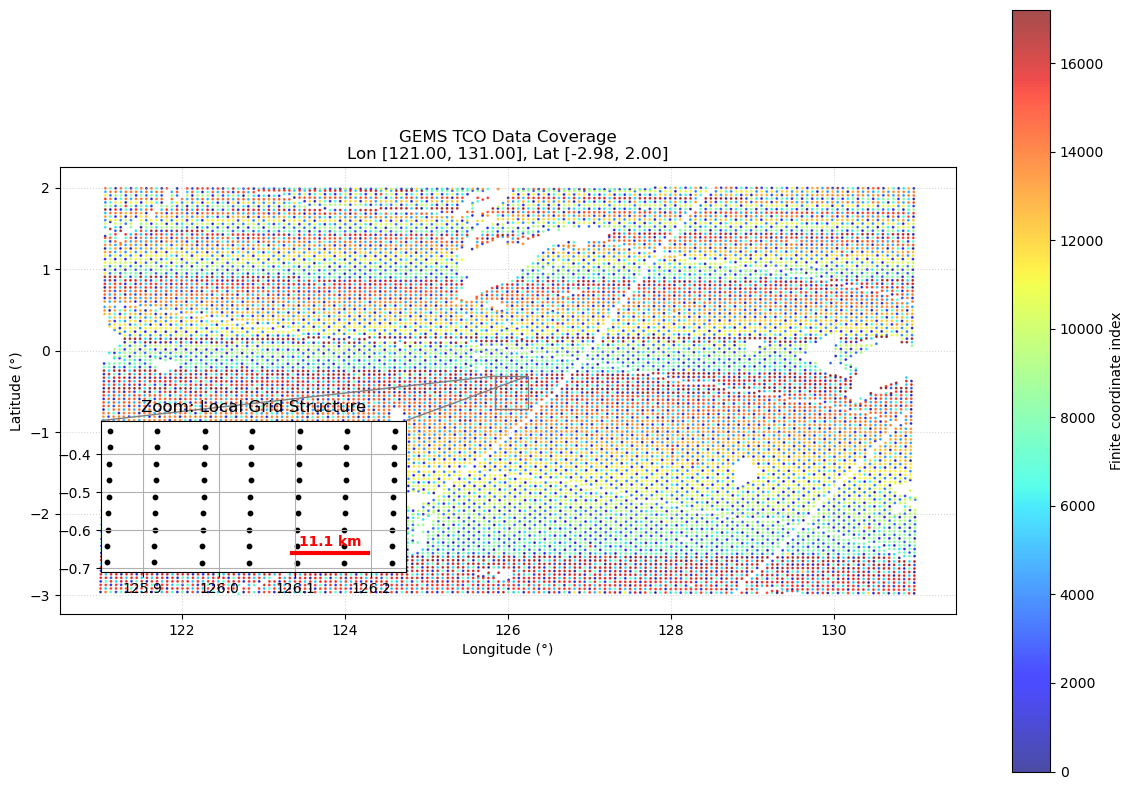

In [72]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Choose a day/hour safely.
day = 10
hour = 4
if day >= len(daily_hourly_maps_dw) or daily_hourly_maps_dw[day] is None:
    raise IndexError(f'day={day} is out of range or empty')

keys = list(daily_hourly_maps_dw[day].keys())
if hour >= len(keys):
    raise IndexError(f'hour={hour} is out of range for day={day}; only {len(keys)} keys')

data_tensor = daily_hourly_maps_dw[day][keys[hour]]
data = data_tensor.detach().cpu().numpy() if isinstance(data_tensor, torch.Tensor) else np.asarray(data_tensor)

coords = np.asarray(data[:, :2], dtype=float)
finite = np.isfinite(coords).all(axis=1)
coords = coords[finite]
if len(coords) == 0:
    raise ValueError('No finite coordinates to plot')

lats = coords[:, 0]
lons = coords[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(lons, lats, c=np.arange(len(lats)), cmap='jet', s=1, alpha=0.7)
plt.colorbar(sc, label='Finite coordinate index')

lon_min = float(np.nanmin(lons))
lon_max = float(np.nanmax(lons))
lat_min = float(np.nanmin(lats))
lat_max = float(np.nanmax(lats))

ax.set_title(
    'GEMS TCO Data Coverage\n'
    f'Lon [{lon_min:.2f}, {lon_max:.2f}], Lat [{lat_min:.2f}, {lat_max:.2f}]'
)
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_aspect('equal')

# Create zoomed inset. The old notebook had this line commented out, causing NameError.
axins = inset_axes(ax, width='34%', height='34%', loc='lower left', borderpad=3)

center_lat = float(np.nanmedian(lats))
center_lon = float(np.nanmedian(lons))
zoom_radius = 0.2
mask = (
    (lats > center_lat - zoom_radius) & (lats < center_lat + zoom_radius)
    & (lons > center_lon - zoom_radius) & (lons < center_lon + zoom_radius)
)
subset_lats = lats[mask]
subset_lons = lons[mask]

if len(subset_lats) == 0:
    # Fallback: plot the nearest 500 points to the median center.
    dist = np.sqrt((lats - center_lat) ** 2 + (lons - center_lon) ** 2)
    idx = np.argsort(dist)[:min(500, len(dist))]
    subset_lats = lats[idx]
    subset_lons = lons[idx]

axins.scatter(subset_lons, subset_lats, c='k', s=10)
axins.set_xlim(center_lon - zoom_radius, center_lon + zoom_radius)
axins.set_ylim(center_lat - zoom_radius, center_lat + zoom_radius)
axins.set_title('Zoom: Local Grid Structure')
axins.grid(True)

km_per_deg = 111.0
scale_bar_deg = 0.1
scale_bar_km = scale_bar_deg * km_per_deg
bar_x = center_lon + zoom_radius * 0.25
bar_y = center_lat - zoom_radius * 0.75

axins.plot([bar_x, bar_x + scale_bar_deg], [bar_y, bar_y], 'r-', linewidth=3)
axins.text(
    bar_x + scale_bar_deg / 2,
    bar_y + 0.02,
    f'{scale_bar_km:.1f} km',
    color='red',
    ha='center',
    fontweight='bold',
    fontsize=10,
)

mark_inset(ax, axins, loc1=2, loc2=1, fc='none', ec='0.5')
plt.tight_layout()
plt.show()


First two latitude rows.

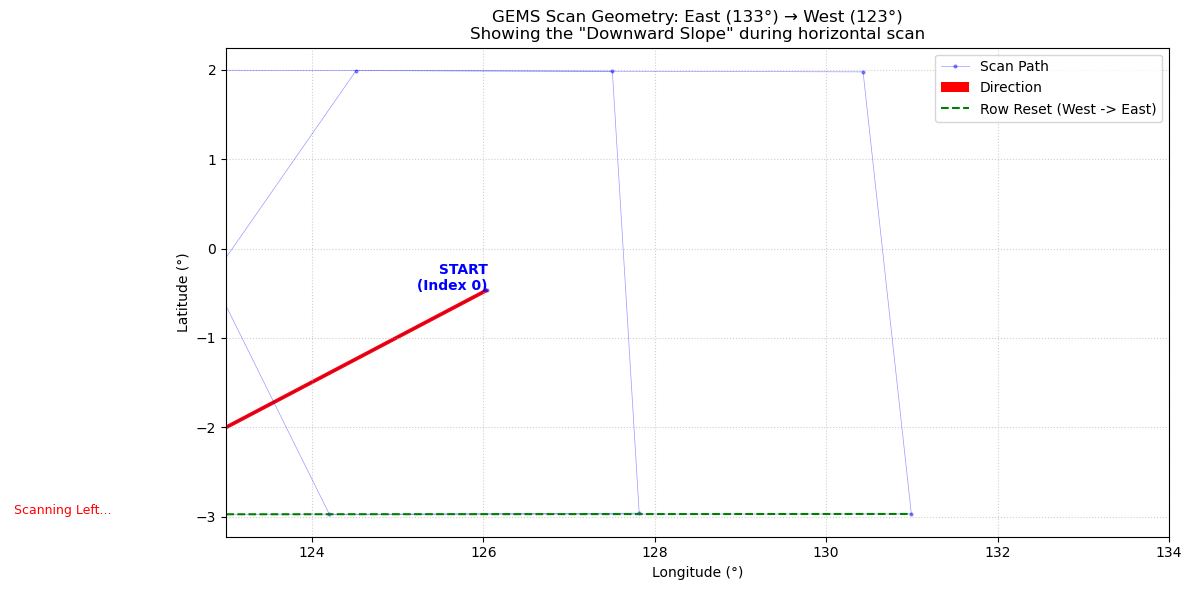

In [73]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load Data ---
day = 1
keys = list(daily_hourly_maps_dw[day].keys())
data_tensor = daily_hourly_maps_dw[day][keys[1]]
data = data_tensor.detach().cpu().numpy() if isinstance(data_tensor, torch.Tensor) else np.asarray(data_tensor)

lats = data[:, 0]
lons = data[:, 1]

# --- 2. Isolate First 2 Rows to "Amplify" the view ---
# Find where the longitude jumps back to the East (Start of new row)
# The diff will be positive and large (~10 degrees) when resetting 123 -> 133
lon_diff = np.diff(lons)
row_starts = np.where(lon_diff > 5.0)[0] + 1 
row_starts = np.insert(row_starts, 0, 0)

# Slice only the first 2 full rows (approx 200-400 points) to keep it clean
if len(row_starts) > 2:
    slice_end = row_starts[2]
else:
    slice_end = len(lats)

sub_lats = lats[:slice_end]
sub_lons = lons[:slice_end]

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(12, 6))

# A. Plot the connected path (The Trace)
ax.plot(sub_lons, sub_lats, 'b.-', markersize=4, linewidth=0.5, alpha=0.4, label='Scan Path')

# B. Add Arrows to show direction (East -> West)
# We plot an arrow every 10 points to avoid clutter
step = 10
# u, v are the components of the arrow vectors
u = np.diff(sub_lons, append=sub_lons[-1])[::step]
v = np.diff(sub_lats, append=sub_lats[-1])[::step]
q_lons = sub_lons[::step]
q_lats = sub_lats[::step]

ax.quiver(q_lons, q_lats, u, v, angles='xy', scale_units='xy', scale=1, 
          color='red', width=0.004, headwidth=4, label='Direction')

# C. Highlight the "Row Jump" (The Reset)
# This connects the end of Row 1 (West) to the start of Row 2 (East)
# We make this a dashed green line to show it's a "reset" motion, not a scan
if len(row_starts) > 1:
    jump_idx = row_starts[1] - 1
    ax.plot(sub_lons[jump_idx:jump_idx+2], sub_lats[jump_idx:jump_idx+2], 
            'g--', linewidth=1.5, label='Row Reset (West -> East)')

# D. Annotate Start and End of the first row to be clear
ax.text(sub_lons[0], sub_lats[0], ' START\n (Index 0)', color='blue', fontweight='bold', ha='right')
if len(row_starts) > 1:
    mid_idx = row_starts[1] // 2
else:
    mid_idx = len(sub_lons) // 2
ax.text(sub_lons[mid_idx], sub_lats[mid_idx], ' Scanning Left...', color='red', fontsize=9, ha='center')

# --- 4. Crucial Formatting for the "Slope" ---
ax.set_title('GEMS Scan Geometry: East (133°) → West (123°)\nShowing the "Downward Slope" during horizontal scan')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')

# FORCE Standard Map Orientation: 123 Left, 133 Right
ax.set_xlim(123, 134) 

# DO NOT use "equal" aspect. 
# We explicitly stretch the Y-axis so a 0.05 degree drop looks huge.
# If your lats are around 4.0 to 5.0, this will auto-scale to show the slant.

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Row 10 and 11

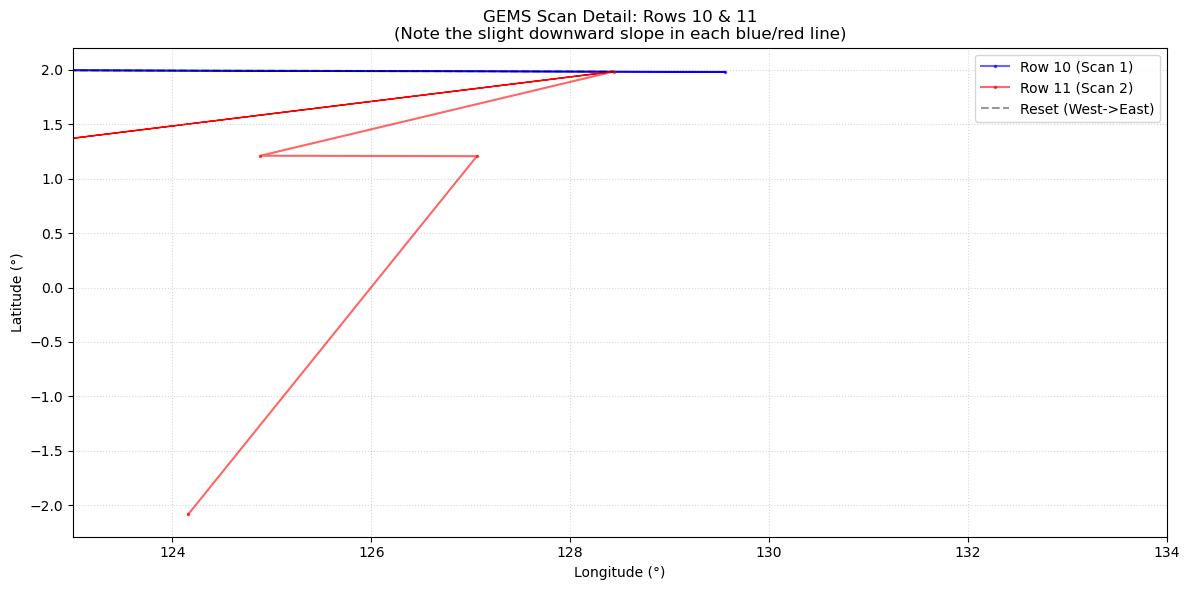

In [74]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load Data ---
day = 1
keys = list(daily_hourly_maps_dw[day].keys())
data_tensor = daily_hourly_maps_dw[day][keys[1]]
data = data_tensor.detach().cpu().numpy() if isinstance(data_tensor, torch.Tensor) else np.asarray(data_tensor)

lats = data[:, 0]
lons = data[:, 1]

# --- 2. Identify Rows ---
# Find indices where Longitude jumps positive (resetting from West back to East)
lon_diff = np.diff(lons)
row_starts = np.where(lon_diff > 5.0)[0] + 1 
row_starts = np.insert(row_starts, 0, 0) # Include the very first start
if len(row_starts) < 3:
    raise ValueError(f'Need at least 2 complete scan rows; detected row_starts={len(row_starts)}')

# --- 3. Select Two "Middle" Consecutive Rows ---
# Let's pick Row 10 and Row 11 (arbitrary middle rows) to avoid edge cases
# If the data is small, we fallback to Row 0 and 1
start_row_idx = 10 if len(row_starts) > 12 else 0

idx_start_1 = row_starts[start_row_idx]
idx_end_1   = row_starts[start_row_idx + 1]
idx_end_2   = row_starts[start_row_idx + 2]

# Extract Data for Row A and Row B
row_a_lons = lons[idx_start_1:idx_end_1]
row_a_lats = lats[idx_start_1:idx_end_1]

row_b_lons = lons[idx_end_1:idx_end_2]
row_b_lats = lats[idx_end_1:idx_end_2]

if len(row_a_lons) < 2 or len(row_b_lons) < 2:
    raise ValueError('Selected scan rows are too short to plot arrows.')

# --- 4. Plotting ---
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Row A (The Upper Row)
ax.plot(row_a_lons, row_a_lats, 'b.-', label=f'Row {start_row_idx} (Scan 1)', markersize=3, alpha=0.6)
# Add arrow for Row A
arrow_idx_a = min(10, len(row_a_lons) - 1)
ax.arrow(row_a_lons[0], row_a_lats[0], row_a_lons[arrow_idx_a]-row_a_lons[0], row_a_lats[arrow_idx_a]-row_a_lats[0], 
         head_width=0.005, color='blue', length_includes_head=True)

# Plot Row B (The Lower Row)
ax.plot(row_b_lons, row_b_lats, 'r.-', label=f'Row {start_row_idx+1} (Scan 2)', markersize=3, alpha=0.6)
# Add arrow for Row B
arrow_idx_b = min(10, len(row_b_lons) - 1)
ax.arrow(row_b_lons[0], row_b_lats[0], row_b_lons[arrow_idx_b]-row_b_lons[0], row_b_lats[arrow_idx_b]-row_b_lats[0], 
         head_width=0.005, color='red', length_includes_head=True)

# Visualize the "Jump" (Reset)
# Connect End of Row A -> Start of Row B
ax.plot([row_a_lons[-1], row_b_lons[0]], [row_a_lats[-1], row_b_lats[0]], 
        'k--', alpha=0.4, label='Reset (West->East)')

# --- 5. Formatting ---
ax.set_title(f'GEMS Scan Detail: Rows {start_row_idx} & {start_row_idx+1}\n(Note the slight downward slope in each blue/red line)')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')

# Standard Map View: 123 Left, 133 Right
ax.set_xlim(123, 134) 

# UNLOCKED Aspect Ratio
# This allows the plot to stretch vertically, making the slope visible.
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()